In [3]:
import pandas as pd

# 1. Load the TSV
#    Adjust the path to wherever your new file lives
meta = pd.read_csv("Data/ALL.plasmid_list.download.tsv", sep="\t", dtype=str)

In [ ]:


# 2. Quick peek at the data
print("First 5 rows:")
display(meta.head())

print("\nDataFrame info:")
print(meta.info())

# 3. Summary statistics
print("\nDescriptive stats (numeric columns):")
print(meta.describe())

print("\nDescriptive stats (all columns):")
print(meta.describe(include="all"))

# 4. Missing values
print("\nMissing values per column:")
print(meta.isnull().sum())

# 5. Unique counts for categorical fields
#    Replace these with the actual column names in your TSV
for col in meta.columns:
    if meta[col].nunique() < 20:  # only show for columns with <20 uniques
        print(f"\nValue counts for {col!r}:")
        print(meta[col].value_counts(dropna=False))

# 6. Overview of column dtypes & memory usage
print("\nColumn dtypes and memory usage:")
print(meta.info(memory_usage="deep"))


First 5 rows:


,Plasmid_ID,Data_Source,Topology,Completeness,Size (bp),GC,Host,MOB_type(s),Predicted_Mobility,Primary_Cluster_ID,Secondary_Cluster_ID
0,EMBL_A00040.1,ENA,linear,incomplete,378,0.574074074074074,Penicillium chrysogenum,-,non-mobilizable,AD768,AN421
1,EMBL_A07921.1,ENA,linear,incomplete,1804,0.581485587583149,-,-,non-mobilizable,AC293,AL417
2,EMBL_A07927.1,ENA,linear,incomplete,1804,0.579822616407982,-,-,non-mobilizable,AC293,AL417
3,EMBL_A15097.1,ENA,linear,incomplete,1906,0.42548709847288,Escherichia coli,-,non-mobilizable,AA816,AJ186
4,EMBL_A17518.1,ENA,linear,incomplete,2054,0.499026290165531,synthetic construct,-,non-mobilizable,AA379,AI397



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852600 entries, 0 to 852599
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Plasmid_ID            852600 non-null  object
 1   Data_Source           852600 non-null  object
 2   Topology              852600 non-null  object
 3   Completeness          852600 non-null  object
 4   Size (bp)             852600 non-null  object
 5   GC                    852600 non-null  object
 6   Host                  852600 non-null  object
 7   MOB_type(s)           852600 non-null  object
 8   Predicted_Mobility    852600 non-null  object
 9   Primary_Cluster_ID    852600 non-null  object
 10  Secondary_Cluster_ID  852600 non-null  object
dtypes: object(11)
memory usage: 71.6+ MB
None

Descriptive stats (numeric columns):
                             Plasmid_ID Data_Source Topology Completeness  \
count                            852600      85

In [4]:


# List of species to check
species_list = [
    "Escherichia coli",
]

for sp in species_list:
    # Mask rows with this species in the Host column (case‐insensitive)
    mask = meta["Host"].str.contains(sp, case=False, na=False)
    n_total = mask.sum()
    # Among those, count “Complete” entries (case‐insensitive)
    n_complete = meta.loc[mask, "Completeness"].str.contains("complete", case=False, na=False).sum()
    # Percentage
    pct = (n_complete / n_total * 100) if n_total else 0
    # Print summary line
    print(f"{sp:<30} total: {n_total:6d}    complete: {n_complete:6d}   ({pct:5.2f}%)\n")


Escherichia coli               total:  30405    complete:  21771   (71.60%)



In [12]:
# 1) Mask for Escherichia coli in species
ecoli_mask = meta["Host"].str.contains(r"(?i)escherichia\s*coli", na=False)

# 2) Subset to those rows
ecoli_df = meta.loc[ecoli_mask].copy()

# 3) Mask for “complete” in Completeness (case‐insensitive)
complete_mask = ecoli_df["Completeness"].str.contains(r"(?i)complete", na=False)

# 4) Count and fraction
n_ecoli = len(ecoli_df)
n_complete = complete_mask.sum()
print(f"Escherichia coli rows total:     {n_ecoli}")
print(f"Of those, Completeness=“complete”: {n_complete}  ({n_complete/n_ecoli:.2%})")

# 5) (Optional) preview
print("\nSample of E. coli rows marked complete:")
display(ecoli_df.loc[complete_mask].head())

Escherichia coli rows total:     30405
Of those, Completeness=“complete”: 21771  (71.60%)

Sample of E. coli rows marked complete:


,Plasmid_ID,Data_Source,Topology,Completeness,Size (bp),GC,Host,MOB_type(s),Predicted_Mobility,Primary_Cluster_ID,Secondary_Cluster_ID
3,EMBL_A15097.1,ENA,linear,incomplete,1906,0.42548709847288,Escherichia coli,-,non-mobilizable,AA816,AJ186
7,EMBL_A24782.1,ENA,circular,complete,7639,0.441288126718157,Escherichia coli,-,non-mobilizable,AB951,AK937
56,DDBJ_AB017809.1,DDBJ,linear,incomplete,1619,0.355775169857937,Escherichia coli,-,non-mobilizable,AE932,AO815
62,DDBJ_AB020531.1,DDBJ,linear,incomplete,6445,0.433048875096974,Escherichia coli,-,non-mobilizable,AA176,AH860
68,DDBJ_AB023657.1,DDBJ,linear,incomplete,282,0.645390070921986,Escherichia coli,-,non-mobilizable,AA664,AI937


In [13]:
ecoli_df.head(10)

,Plasmid_ID,Data_Source,Topology,Completeness,Size (bp),GC,Host,MOB_type(s),Predicted_Mobility,Primary_Cluster_ID,Secondary_Cluster_ID
3,EMBL_A15097.1,ENA,linear,incomplete,1906,0.42548709847288,Escherichia coli,-,non-mobilizable,AA816,AJ186
6,EMBL_A23334.1,ENA,linear,-,5620,0.478632478632479,Escherichia coli,-,non-mobilizable,AB951,AK937
7,EMBL_A24782.1,ENA,circular,complete,7639,0.441288126718157,Escherichia coli,-,non-mobilizable,AB951,AK937
56,DDBJ_AB017809.1,DDBJ,linear,incomplete,1619,0.355775169857937,Escherichia coli,-,non-mobilizable,AE932,AO815
62,DDBJ_AB020531.1,DDBJ,linear,incomplete,6445,0.433048875096974,Escherichia coli,-,non-mobilizable,AA176,AH860
68,DDBJ_AB023657.1,DDBJ,linear,incomplete,282,0.645390070921986,Escherichia coli,-,non-mobilizable,AA664,AI937
70,"DDBJ_AB024946.1,IMGPR_plasmid_640048319_000001...","DDBJ,IMG-PR,RefSeq",linear,complete,68817,0.460249647616141,"Escherichia coli,-",-,non-mobilizable,AB269,AJ980
83,DDBJ_AB038042.1,DDBJ,linear,incomplete,4070,0.615233415233415,Escherichia coli,-,non-mobilizable,AE581,AO395
84,DDBJ_AB038654.1,DDBJ,linear,incomplete,6254,0.414774544291653,Escherichia coli,-,non-mobilizable,AB951,AK938
85,"DDBJ_AB038771.1,GenBank_FJ405213.1,GenBank_FJ4...","DDBJ,GenBank,GenBank,GenBank,GenBank,GenBank,G...",linear,incomplete,876,0.605022831050228,"Escherichia coli,Klebsiella pneumoniae",-,non-mobilizable,AB957,AK945


In [14]:
# Number of rows in Ecoli dataframe
n_rows_ecoli = len(ecoli_df)
print(f"\nTotal number of rows in E. coli dataframe: {n_rows_ecoli}")
# Save the E. coli dataframe to a new TSV file
ecoli_df.to_csv("Data/Ecoli_plasmids.tsv", sep="\t", index=False)
# Confirmation message
print("E. coli plasmids data saved to 'Data/Ecoli_plasmids.tsv' successfully.")


Total number of rows in E. coli dataframe: 30405
E. coli plasmids data saved to 'Data/Ecoli_plasmids.tsv' successfully.


In [15]:
# Count unique Data_Source values
unique_data_sources = ecoli_df["Data_Source"].nunique()
print(f"\nNumber of unique Data_Source values in E. coli dataframe: {unique_data_sources}")


Number of unique Data_Source values in E. coli dataframe: 253


In [10]:
import pandas as pd

# 1) Load your TSV
df = pd.read_csv("/cs/student/projects1/aibh/2024/acunning/Projects/Data/Ecoli_plasmids.tsv", sep="\t", dtype=str)

# 2) Split the comma-separated lists into individual rows
#    - First, fill NaN with empty string so split won’t error
#    - Then split on ',', strip whitespace, explode into one row per source
sources = (
    df["Data_Source"]
    .fillna("")                        # turn NaN into ""
    .str.split(",")                    # list of sources
    .apply(lambda lst: [s.strip() for s in lst if s.strip()])  # strip & drop empties
    .explode()                         # one source per row
)

# 3) Count how many times each source appears
counts = sources.value_counts()

# 4) Display the breakdown
print("Datasource counts (including multi-source entries):")
print(counts)

# 5) If you want percentages as well:
total_rows = len(df)
pct = (counts / total_rows * 100).round(2)
print("\nDatasource percentages (of total rows):")
print(pct)

# 6) (Optional) Show them side by side
breakdown = pd.DataFrame({
    "count": counts,
    "percent": pct
})
display(breakdown)



Datasource counts (including multi-source entries):
GenBank    22394
RefSeq     19528
PLDSB       9511
IMG-PR      6610
DDBJ        1712
COMPASS     1688
ENA          978
Kraken2       78
TPA            1
Name: Data_Source, dtype: int64

Datasource percentages (of total rows):
GenBank    73.65
RefSeq     64.23
PLDSB      31.28
IMG-PR     21.74
DDBJ        5.63
COMPASS     5.55
ENA         3.22
Kraken2     0.26
TPA         0.00
Name: Data_Source, dtype: float64


,count,percent
GenBank,22394,73.65
RefSeq,19528,64.23
PLDSB,9511,31.28
IMG-PR,6610,21.74
DDBJ,1712,5.63
COMPASS,1688,5.55
ENA,978,3.22
Kraken2,78,0.26
TPA,1,0.00


In [9]:

# 2) Split & explode into one row per individual source
df = df.assign(
    source = df["Data_Source"]
               .fillna("")            # turn NaN into ""
               .str.split(",")        # list of sources
).explode("source")                        # one source per row

# 3) Clean up whitespace & drop any empty strings
df["source"] = df["source"].str.strip()
df = df[df["source"] != ""]

# 4) Build a completeness flag
df["completeness_flag"] = (
    df["Completeness"]
      .str.contains(r"(?i)complete", na=False)
      .map({True: "complete", False: "incomplete"})
)

# 5) Crosstab: each unique 'source' × Complete vs Incomplete
pivot = pd.crosstab(df["source"], df["completeness_flag"])

# 6) Add totals & sort by total count
pivot["Total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("Total", ascending=False)

# 7) Display the result
print("Complete vs Incomplete by datasource:")
display(pivot)


Complete vs Incomplete by datasource:


completeness_flag,complete,incomplete,Total
source,,,
GenBank,10848,7863,18711
RefSeq,8171,7827,15998
PLDSB,6439,376,6815
IMG-PR,5581,89,5670
DDBJ,1198,176,1374
COMPASS,1160,0,1160
ENA,444,21,465
Kraken2,44,5,49
TPA,1,0,1


In [1]:
import shutil
from pathlib import Path

# List of source subdirectories containing FASTAs
source_dirs = [
    "/cs/student/projects1/aibh/2024/acunning/GenBank/fasta",
    "/cs/student/projects1/aibh/2024/acunning/RefSeq/fasta",
    "/cs/student/projects1/aibh/2024/acunning/PLSDB/fasta",
    "/cs/student/projects1/aibh/2024/acunning/IMG-PR/fasta",
    "/cs/student/projects1/aibh/2024/acunning/DDBJ/fasta",
    "/cs/student/projects1/aibh/2024/acunning/COMPASS/fasta"
]

# Destination directory
dest_dir = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta")
dest_dir.mkdir(parents=True, exist_ok=True)

for sd in source_dirs:
    sd_path = Path(sd)
    if not sd_path.is_dir():
        print(f"Warning: source directory {sd_path} not found; skipping.")
        continue
    # Copy both .fa and .fasta
    for pattern in ("*.fa", "*.fasta"):
        for fpath in sd_path.glob(pattern):
            dest = dest_dir / fpath.name
            # If file already exists, prefix with source dirname
            if dest.exists():
                dest = dest_dir / f"{sd_path.name}_{fpath.name}"
            shutil.copy2(fpath, dest)

print(f"All FASTA files have been combined into: {dest_dir.resolve()}") 


All FASTA files have been combined into: /cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta


In [2]:
import pandas as pd
from pathlib import Path

# 1) Set this to the actual path of your Ecoli_plasmids.tsv:
tsv_path = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/Ecoli_plasmids.tsv"
# 2) Path to the combined FASTA folder
fasta_dir = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta")

# 3) Load the TSV
df = pd.read_csv(tsv_path, sep="\t", dtype=str)

deleted = []

# 4) Helper to get sequence length without Biopython
def get_seq_length(p: Path) -> int:
    length = 0
    with p.open() as f:
        for line in f:
            if line.startswith(">"):
                continue
            length += len(line.strip())
    return length

# 5) For each row of equivalent IDs, delete shorter duplicates
for _, row in df.iterrows():
    # Parse comma-separated Plasmid IDs
    id_list = [pid.strip() for pid in row["Plasmid_ID"].split(",") if pid.strip()]
    # Gather all existing FASTA paths for those IDs
    fasta_paths = []
    for pid in id_list:
        for ext in (".fa", ".fasta"):
            p = fasta_dir / f"{pid}{ext}"
            if p.exists():
                fasta_paths.append(p)
                break

    # If more than one file, keep only the longest
    if len(fasta_paths) > 1:
        lengths = {p: get_seq_length(p) for p in fasta_paths}
        keep = max(lengths, key=lengths.get)
        for p in fasta_paths:
            if p != keep:
                p.unlink()
                deleted.append(str(p))

print(f"Deleted {len(deleted)} duplicate FASTA files. Sample deletions:")
print(deleted[:10])


Deleted 30682 duplicate FASTA files. Sample deletions:
['/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/RefSeq_NC_002142.1.fasta', '/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/GenBank_FJ405213.1.fa', '/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/GenBank_FJ405218.1.fa', '/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/GenBank_FJ405221.1.fa', '/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/GenBank_FJ424731.1.fa', '/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/GenBank_FJ424732.1.fa', '/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/GenBank_FJ424733.1.fa', '/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/GenBank_GU211011.1.fa', '/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/GenBank_MG757244.1.fa', '/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/DDBJ_AB168117.1.fa']


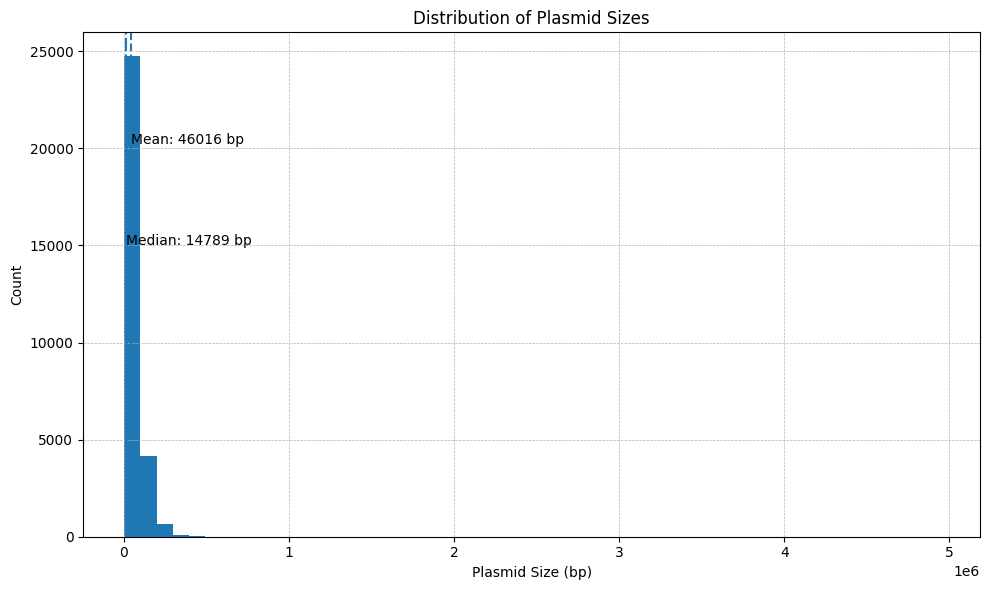

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load the TSV (adjust the path as needed)
ecolidf = pd.read_csv(
    "/cs/student/projects1/aibh/2024/acunning/Projects/Data/Ecoli_plasmids_final.tsv",
    sep="\t",
    dtype=str
)

# 2) Convert Size (bp) to numeric, drop invalid entries
ecolidf["Size (bp)"] = pd.to_numeric(ecolidf["Size (bp)"], errors="coerce")
sizes = ecolidf["Size (bp)"].dropna()

# 3) Plot histogram
# 4) Compute mean and median
mean_size = sizes.mean()
median_size = sizes.median()

# 5) Create a larger, cleaner histogram
plt.figure(figsize=(10, 6))
plt.hist(sizes, bins=50)
# Add vertical lines for mean and median
plt.axvline(mean_size, linestyle='--', linewidth=1.5)
plt.axvline(median_size, linestyle='-.', linewidth=1.5)
# Annotate mean and median
ylim = plt.ylim()
plt.text(mean_size, ylim[1] * 0.8, f"Mean: {mean_size:.0f} bp", va='top')
plt.text(median_size, ylim[1] * 0.6, f"Median: {median_size:.0f} bp", va='top')
# Add grid and labels
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel("Plasmid Size (bp)")
plt.ylabel("Count")
plt.title("Distribution of Plasmid Sizes")
plt.tight_layout()
plt.show()



## Adjusting metadata

In [ ]:


import pandas as pd
from pathlib import Path

# 1) Update paths if needed
tsv_path = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/Ecoli_plasmids_final.tsv"
fasta_dir = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta")

# 2) Load metadata
df = pd.read_csv(tsv_path, sep="\t", dtype=str)

# 3) Collect FASTA IDs (stems)
fasta_ids = {p.stem for p in fasta_dir.glob("*")}

# 4) Filter rows: keep if any ID in the comma‐separated 'Plasmid ID' is in fasta_ids
def has_fasta(cell: str) -> bool:
    return any(pid.strip() in fasta_ids for pid in cell.split(","))

mask = df["Plasmid_ID"].apply(has_fasta)
df_final = df.loc[mask].copy()

# 5) Summary
print(f"Original metadata rows: {len(df)}")
print(f"Filtered metadata rows: {len(df_final)}")

# 6) Save filtered metadata
output_path = "Ecoli_plasmids_ft.tsv"
df_final.to_csv(output_path, sep="\t", index=False)
print(f"Filtered metadata written to {output_path}")


Original metadata rows: 29608
Filtered metadata rows: 24846
Filtered metadata written to Ecoli_plasmids_ft.tsv


## Size analysis

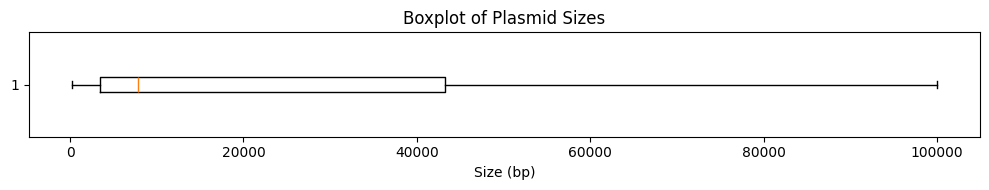

Mean plasmid size: 25384 bp
Median plasmid size: 7798 bp


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

tsv_path = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/Ecoli_plasmids_ft.tsv"

# 2) Load metadata
df = pd.read_csv(tsv_path, sep="\t", dtype=str)

# 2) Parse sizes
df["Size"] = pd.to_numeric(df["Size (bp)"], errors="coerce")
sizes = df["Size"].dropna()

# 3) Compute 5th and 95th percentiles to trim extremes
p05, p95 = sizes.quantile(0.0), sizes.quantile(1.0)

# 4) Clip the series so values outside [p05, p95] are set to the percentiles
sizes_clipped = sizes.clip(lower=p05, upper=p95)

# 5) Draw a wide, flat boxplot
plt.figure(figsize=(10, 2), dpi=100)
plt.boxplot(sizes_clipped, vert=False, 
            flierprops=dict(marker='.', markersize=4, alpha=0.5))
plt.xlabel("Size (bp)")
plt.title("Boxplot of Plasmid Sizes")
plt.tight_layout()
plt.show()

# mean and median plasmid sizes
mean_size = sizes.mean()
median_size = sizes.median()
print(f"Mean plasmid size: {mean_size:.0f} bp")
print(f"Median plasmid size: {median_size:.0f} bp")



In [ ]:
# Check data source distribution from name in plasmid ID in raw fasta file name
import pandas as pd
from pathlib import Path
# 1) Load the TSV
tsv_path = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/Ecoli_plasmids_ft.tsv"
df = pd.read_csv(tsv_path, sep="\t", dtype=str) 
# 2) Split the comma-separated lists into individual rows
#    - First, fill NaN with empty string so split won’t error
#    - Then split on ',', strip whitespace, explode into one row per source
sources = (
    df["Data_Source"]
    .fillna("")                        # turn NaN into ""
    .str.split(",")                    # list of sources
    .apply(lambda lst: [s.strip() for s in lst if s.strip()])  # strip & drop empties
    .explode()                         # one source per row
)   
# 3) Count how many times each source appears
counts = sources.value_counts()
# 4) Display the breakdown
print("Datasource counts (including multi-source entries):")
print(counts)

# 5 print table with counts
breakdown = pd.DataFrame({
    "count": counts,
})

Datasource counts (including multi-source entries):
Data_Source
GenBank    18711
RefSeq     15998
PLDSB       6815
IMG-PR      5670
DDBJ        1374
COMPASS     1160
ENA          465
Kraken2       49
TPA            1
Name: count, dtype: int64


In [ ]:

# 3) Convert Size (bp) to numeric, drop missing
df["Size"] = pd.to_numeric(df["Size (bp)"], errors="coerce")
df = df.dropna(subset=["Size"])

# 4) Compute percentiles
p05 = df["Size"].quantile(0.05)
p95 = df["Size"].quantile(0.95)
print(f"5th percentile plasmid size:  {p05:.0f} bp")
print(f"95th percentile plasmid size: {p95:.0f} bp\n")

# 5) Display top 50 longest plasmids
top50 = df.sort_values("Size", ascending=False).head(1000)[["Plasmid_ID", "Size"]]
print("Top 50 longest plasmids:")
display(top50)

# 6) Display bottom 50 shortest plasmids
bottom50 = df.sort_values("Size", ascending=True).head(1000)[["Plasmid_ID", "Size"]]
print("\nBottom 50 shortest plasmids:")
display(bottom50)


5th percentile plasmid size:  818 bp
95th percentile plasmid size: 151643 bp

Top 50 longest plasmids:


,Plasmid_ID,Size
15917,"GenBank_CP141089.1,RefSeq_NZ_CP141089.1",4938057
15781,"GenBank_CP134663.1,RefSeq_NZ_CP134663.1",4902913
18650,RefSeq_NZ_OL790696.1,4795340
4684,"GenBank_CP061244.1,PLSDB_CP061244.1",1412998
7579,"GenBank_CP099174.1,PLSDB_CP099174.1",1310597
...,...,...
11443,"COMPASS_KX156773.1,GenBank_KX156773.1,RefSeq_N...",173094
16987,RefSeq_NZ_JAXHSO010000002.1,173057
12345,"EMBL_LS992169.1,PLSDB_NZ_LS992169.1,RefSeq_NZ_...",172923
2811,"GenBank_CP046718.1,PLSDB_NZ_CP046718.1,RefSeq_...",172892



Bottom 50 shortest plasmids:


,Plasmid_ID,Size
11782,DDBJ_LC318121.1,201
11719,DDBJ_LC318039.1,201
12991,GenBank_MH846755.1,202
17197,"GenBank_LHAT01000200.1,RefSeq_NZ_LHAT01000200.1",202
18253,"GenBank_MT230284.1,RefSeq_NZ_MT230284.1",202
...,...,...
13413,GenBank_MH847609.1,588
10796,GenBank_JN636791.1,588
11767,DDBJ_LC318104.1,589
13344,GenBank_MH847444.1,589


In [1]:
import pandas as pd
from pathlib import Path
import shutil

# 1) Paths
tsv_path    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/Ecoli_plasmids_final.tsv"
fasta_dir   = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta")
dest_dir    = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/30k_bp_fasta")

# 2) Load metadata and parse sizes
df = pd.read_csv(tsv_path, sep="\t", dtype=str)
df["Size"] = pd.to_numeric(df["Size (bp)"], errors="coerce")

# 3) Identify all plasmid IDs whose size > 30 000 bp
large_df = df[df["Size"] > 30_000]
large_ids = large_df["Plasmid_ID"].dropna().tolist()

# 4) Prepare destination directory
dest_dir.mkdir(parents=True, exist_ok=True)

# 5) Move each matching FASTA file
moved = 0
for cell in large_ids:
    for pid in cell.split(","):
        pid = pid.strip()
        for ext in (".fa", ".fasta"):
            src = fasta_dir / f"{pid}{ext}"
            if src.exists():
                shutil.move(str(src), str(dest_dir / src.name))
                moved += 1
                break  # go to next pid once moved

print(f"Moved {moved} FASTA files >100 000 bp to {dest_dir.resolve()}")


Moved 7917 FASTA files >100 000 bp to /cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/30k_bp_fasta


In [11]:
# Chek percentage completeness of plasmids

# 3) Count total rows and complete entries
total_rows = len(df)
complete_rows = df["Completeness"].str.contains("complete", case=False, na=False).sum()
# 4) Calculate percentage
percentage_complete = (complete_rows / total_rows * 100) if total_rows else 0
# 5) Print summary
print(f"Total rows: {total_rows}")
print(f"Complete entries: {complete_rows} ({percentage_complete:.2f}%)")        

Total rows: 24846
Complete entries: 16643 (66.98%)


### ARG analysis

In [7]:
arg = pd.read_csv('/cs/student/projects1/aibh/2024/acunning/Projects/Data/arg_final.tsv', sep="\t", dtype=str)
# 6) Display the first few rows of the DataFrame
print("First few rows of the ARG DataFrame:")
display(arg.head())

First few rows of the ARG DataFrame:


,Plasmid_ID,Protein_ID,Orf Prediction Source,Start,End,Strand,Product,Cut_Off,HSP identifier,Best_Hit_ARO,Best_Identities,ARO,Drug Class,Resistance Mechanism,AMR Gene Family,Antibiotic,Sequence,SNPs_in_Best_Hit_ARO,Other_SNPs
0,COMPASS_AF197335.1,HCEFDFCM_02261,Prodigal:2.6,1053,2909,+,Colicin-B,Loose,gnl|BL_ORD_ID|145|hsp_num:0,tet(42),36.67,3000572,tetracycline antibiotic,antibiotic efflux,major facilitator superfamily (MFS) antibiotic...,tetracycline,MPGFNYGGYGDGTGWSSESGGPAPGGGMHGNSGGQRGDNANSSNSV...,NaN,NaN
1,COMPASS_AF197335.1,HCEFDFCM_02264,Prodigal:2.6,4731,4925,-,Regulatory protein rop,Loose,gnl|BL_ORD_ID|577|hsp_num:0,smeF,32.08,3003057,macrolide antibiotic; fluoroquinolone antibiot...,antibiotic efflux,resistance-nodulation-cell division (RND) anti...,tetracycline; chloramphenicol,MNKQQQTALNMARFIKSQSLTLLEKLDALDADEQAAMCERLHELAE...,NaN,NaN
2,COMPASS_AY360321.1,HCEFDFCM_06857,Prodigal:2.6,25,840,+,Dihydropteroate synthase,Perfect,gnl|BL_ORD_ID|873|hsp_num:0,sul2,100.0,3000412,sulfonamide antibiotic,antibiotic target replacement,sulfonamide resistant sul,sulfadiazine; sulfadimidine; sulfadoxine; sulf...,MNKSLIIFGIVNITSDSFSDGGRYLAPDAAIAQARKLMAEGADVID...,NaN,NaN
3,COMPASS_AY360321.1,HCEFDFCM_06858,Prodigal:2.6,901,1704,+,Aminoglycoside 3'-phosphotransferase,Strict,gnl|BL_ORD_ID|1688|hsp_num:0,APH(3'')-Ib,99.63,3002639,aminoglycoside antibiotic,antibiotic inactivation,APH(3''),streptomycin,MNRTNIFFGESHSDWLPVRGGESGDFVFRRGDGHAFAKIAPASRRG...,NaN,NaN
4,COMPASS_AY360321.1,HCEFDFCM_06859,Prodigal:2.6,1704,2540,+,hypothetical protein,Strict,gnl|BL_ORD_ID|949|hsp_num:0,APH(6)-Id,99.64,3002660,aminoglycoside antibiotic,antibiotic inactivation,APH(6),streptomycin,MFMPPVFPAHWHVSQPVLIADTFSSLVWKVSLPDGTPAIVKGLKPI...,NaN,NaN


In [8]:
# export first 10 rows to a new file
arg.head(10).to_csv('/cs/student/projects1/aibh/2024/acunning/Projects/Data/arg_first_10.tsv', sep="\t", index=False)
print("First 10 rows of ARG DataFrame exported to 'arg_first_10.tsv' successfully.")

First 10 rows of ARG DataFrame exported to 'arg_first_10.tsv' successfully.


In [6]:


import pandas as pd
from pathlib import Path

# 1) Update paths if needed
tsv_path = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/ALL.ARG_list.tsv"
fasta_dir = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta")


# 3) Collect FASTA IDs (stems)
fasta_ids = {p.stem for p in fasta_dir.glob("*")}

# 4) Filter rows: keep if any ID in the comma‐separated 'Plasmid ID' is in fasta_ids
def has_fasta(cell: str) -> bool:
    return any(pid.strip() in fasta_ids for pid in cell.split(","))

mask = arg["Plasmid_ID"].apply(has_fasta)
arg_final = arg.loc[mask].copy()

# 5) Summary
print(f"Original metadata rows: {len(arg)}")
print(f"Filtered metadata rows: {len(arg_final)}")

# 6) Save filtered metadata
output_path = "arg_final.tsv"
arg_final.to_csv(output_path, sep="\t", index=False)
print(f"Filtered metadata written to {output_path}")


Original metadata rows: 21090397
Filtered metadata rows: 547714
Filtered metadata written to arg_final.tsv


In [3]:
import pandas as pd

arg = pd.read_csv('/cs/student/projects1/aibh/2024/acunning/Projects/Data/arg_final.tsv', sep="\t", dtype=str)

# unique plasmid IDs in arg_final
unique_plasmid_ids = arg["Plasmid_ID"].nunique()
print(f"Number of unique plasmid IDs in arg_final: {unique_plasmid_ids}")

Number of unique plasmid IDs in arg_final: 23649


In [6]:
import pandas as pd

# number of unique Antibiotic
meta = pd.read_csv('/cs/student/projects1/aibh/2024/acunning/Projects/Data/arg_final.tsv', sep="\t", dtype=str)
unique_growth_bacteria = meta["Antibiotic"].nunique()
print(f"\nNumber of unique values in 'Antibiotic': {unique_growth_bacteria}")

# in first word of Antibiotic
# meta["Antibiotic"] = meta["Antibiotic"].str.split().str[2]
print("new")
print("\nFirst word in 'Antibiotic':")
# print(meta["Antibiotic"].unique())
print(f"\nNumber of unique first words in 'Antibiotic': {meta['Antibiotic'].nunique()}")

# Check for plasmids with no Antibiotic
no_growth_bacteria = meta[meta["Antibiotic"].isna()]
print(f"\nNumber of plasmids with no 'Antibiotic': {len(no_growth_bacteria)}")

# Counts of words in 'Antibiotic'
first_word_counts = meta["Antibiotic"].value_counts()
print("\nCounts of first words in 'Antibiotic':")
print(first_word_counts)

# Counts of top 10 words in 'Antibiotic'
top_10_first_words = first_word_counts.head(10)
print("\nTop 10 first words in 'Antibiotic':")
print(top_10_first_words)

# counts of Ampicillin, Kanamycin, Chloramphenicol, Streptomycin in antibiotic
antibiotics_of_interest = ["ampicillin", "Kanamycin", "chloramphenicol", "streptomycin", "gentamycin"]
antibiotic_counts = meta["Antibiotic"].value_counts()
for antibiotic in antibiotics_of_interest:
    count = antibiotic_counts.get(antibiotic, 0)
    print(f"\nCount of '{antibiotic}': {count}")    



Number of unique values in 'Antibiotic': 359
new

First word in 'Antibiotic':

Number of unique first words in 'Antibiotic': 359

Number of plasmids with no 'Antibiotic': 107977

Counts of first words in 'Antibiotic':
Antibiotic
oxacillin                                                                         29458
tetracycline                                                                      23696
vancomycin                                                                        19538
colistin A; colistin B                                                            15409
trimethoprim                                                                      11525
                                                                                  ...  
ceftazidime; meropenem                                                                1
nalidixic acid; norfloxacin                                                           1
enacyloxin IIa                                                    

### Continue

In [33]:
# Count number of complete plasmids in Ecoli_plasmids_ft.tsv
import pandas as pd
ecoli = pd.read_csv('/cs/student/projects1/aibh/2024/acunning/Projects/Data/Ecoli_plasmids_complete.tsv', sep="\t", dtype=str)
total_plasmids = len(ecoli)
print(f"\nTotal number of plasmids in Ecoli_plasmids_ft.tsv: {total_plasmids}")
complete_plasmids = ecoli[ecoli["Completeness"].str.lower() == "complete"]
incomplete_plasmids = ecoli[ecoli["Completeness"].str.lower() == "incomplete"]
print(f"\nNumber of complete plasmids in Ecoli_plasmids_ft.tsv: {len(complete_plasmids)}")
print(f"\nNumber of incomplete plasmids in Ecoli_plasmids_ft.tsv: {len(incomplete_plasmids)}")

# distinct values in Completeness column
distinct_completeness = ecoli["Completeness"].unique()
print(f"\nDistinct values in 'Completeness' column: {distinct_completeness}")


Total number of plasmids in Ecoli_plasmids_ft.tsv: 11468

Number of complete plasmids in Ecoli_plasmids_ft.tsv: 11468

Number of incomplete plasmids in Ecoli_plasmids_ft.tsv: 0

Distinct values in 'Completeness' column: ['complete']


In [27]:
ecoli.head(10)

,Plasmid_ID,Data_Source,Topology,Completeness,Size (bp),GC,Host,MOB_type(s),Predicted_Mobility,Primary_Cluster_ID,Secondary_Cluster_ID
0,DDBJ_AB017809.1,DDBJ,linear,incomplete,1619,0.355775169857937,Escherichia coli,-,non-mobilizable,AE932,AO815
1,DDBJ_AB020531.1,DDBJ,linear,incomplete,6445,0.433048875096974,Escherichia coli,-,non-mobilizable,AA176,AH860
2,DDBJ_AB023657.1,DDBJ,linear,incomplete,282,0.645390070921986,Escherichia coli,-,non-mobilizable,AA664,AI937
3,"DDBJ_AB024946.1,IMGPR_plasmid_640048319_000001...","DDBJ,IMG-PR,RefSeq",linear,complete,68817,0.460249647616141,"Escherichia coli,-",-,non-mobilizable,AB269,AJ980
4,DDBJ_AB038042.1,DDBJ,linear,incomplete,4070,0.615233415233415,Escherichia coli,-,non-mobilizable,AE581,AO395
5,DDBJ_AB038654.1,DDBJ,linear,incomplete,6254,0.414774544291653,Escherichia coli,-,non-mobilizable,AB951,AK938
6,"DDBJ_AB038771.1,GenBank_FJ405213.1,GenBank_FJ4...","DDBJ,GenBank,GenBank,GenBank,GenBank,GenBank,G...",linear,incomplete,876,0.605022831050228,"Escherichia coli,Klebsiella pneumoniae",-,non-mobilizable,AB957,AK945
7,"DDBJ_AB059404.1,DDBJ_AB168117.1,DDBJ_AB185834....","DDBJ,DDBJ,DDBJ,DDBJ,DDBJ,DDBJ,DDBJ,DDBJ,DDBJ,DDBJ",linear,incomplete,876,0.549086757990868,"Escherichia coli,Enterobacter cloacae,Klebsiel...",-,non-mobilizable,AB953,AK940
8,DDBJ_AB061794.1,DDBJ,linear,incomplete,8049,0.547645670269599,Escherichia coli,-,non-mobilizable,AC293,AL417
9,DDBJ_AB098539.1,DDBJ,linear,incomplete,1020,0.543137254901961,Escherichia coli,-,non-mobilizable,AB953,AK940


In [34]:
# Check number of plasmids with circular in topology
circular_plasmids = ecoli[ecoli["Topology"].str.contains("circular", case=False, na=False)]
print(f"\nNumber of plasmids with 'circular' in Topology: {len(circular_plasmids)}")
linear_plasmids = ecoli[ecoli["Topology"].str.contains("linear", case=False, na=False)]
print(f"\nNumber of plasmids with 'linear' in Topology: {len(linear_plasmids)}")
concatemer_plasmids = ecoli[ecoli["Topology"].str.contains("concatemer", case=False, na=False)]
print(f"\nNumber of plasmids with 'concatemer' in Topology: {len(concatemer_plasmids)}")
direct_plasmids = ecoli[ecoli["Topology"].str.contains("direct terminal repeat", case=False, na=False)]
print(f"\nNumber of plasmids with 'direct terminal repeat' in Topology: {len(direct_plasmids)}")
inverted_plasmids = ecoli[ecoli["Topology"].str.contains("inverted terminal repeat", case=False, na=False)]
print(f"\nNumber of plasmids with 'inverted terminal repeat' in Topology: {len(inverted_plasmids)}")
# distinct values in Topology column
distinct_topology = ecoli["Topology"].unique()
print(f"\nDistinct values in 'Topology' column: {distinct_topology}")


Number of plasmids with 'circular' in Topology: 9565

Number of plasmids with 'linear' in Topology: 341

Number of plasmids with 'concatemer' in Topology: 0

Number of plasmids with 'direct terminal repeat' in Topology: 1561

Number of plasmids with 'inverted terminal repeat' in Topology: 1

Distinct values in 'Topology' column: ['linear' 'circular' 'direct terminal repeat' 'inverted terminal repeat']


In [38]:
import pandas as pd

# Paths
complete_path = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/Ecoli_plasmids_complete.tsv"
circular_path = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/circular_complete.tsv"
noncircular_path = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/noncircular_complete.tsv"

# Load complete plasmids file
complete_df = pd.read_csv(complete_path, sep="\t", dtype=str)

# Normalise Topology column (strip + lowercase for consistency)
complete_df["Topology"] = complete_df["Topology"].str.strip().str.lower()

# Split into circular vs non-circular
circular_df = complete_df[complete_df["Topology"] == "circular"]
noncircular_df = complete_df[complete_df["Topology"] != "circular"]

# Save to new files
circular_df.to_csv(circular_path, sep="\t", index=False)
noncircular_df.to_csv(noncircular_path, sep="\t", index=False)

print(f"Saved {len(circular_df)} circular plasmids → {circular_path}")
print(f"Saved {len(noncircular_df)} non-circular plasmids → {noncircular_path}")


Saved 9565 circular plasmids → /cs/student/projects1/aibh/2024/acunning/Projects/Data/circular_complete.tsv
Saved 1903 non-circular plasmids → /cs/student/projects1/aibh/2024/acunning/Projects/Data/noncircular_complete.tsv


In [39]:
# Move all incomplete plasmids to a new folder
import pandas as pd
from pathlib import Path
import shutil
incomplete_tsv = '/cs/student/projects1/aibh/2024/acunning/Projects/Data/noncircular_complete.tsv'
incomplete_df = pd.read_csv(incomplete_tsv, sep="\t", dtype=str)
fasta_dir   = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta")
dest_dir    = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/noncircular_complete_fasta")
dest_dir.mkdir(parents=True, exist_ok=True)
moved = 0
for cell in incomplete_df["Plasmid_ID"]:
    for pid in cell.split(","):
        pid = pid.strip()
        for ext in (".fa", ".fasta"):
            src = fasta_dir / f"{pid}{ext}"
            if src.exists():
                shutil.move(str(src), str(dest_dir / src.name))
                moved += 1
                break  # go to next pid once moved
print(f"Moved {moved} FASTA files of incomplete plasmids to {dest_dir.resolve()}")

Moved 1718 FASTA files of incomplete plasmids to /cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/noncircular_complete_fasta


In [41]:
# Check how many fastas are left in the original fasta folder
import pandas as pd
from pathlib import Path
import shutil
fasta_dir   = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta")
remaining_fastas = list(fasta_dir.glob("*"))
print(f"\nNumber of FASTA files remaining in original folder: {len(remaining_fastas)}")


Number of FASTA files remaining in original folder: 14485



Min FASTA length: 0 bp
Max FASTA length: 29986 bp
Mean FASTA length: 6457.91 bp
Median FASTA length: 5612.0 bp


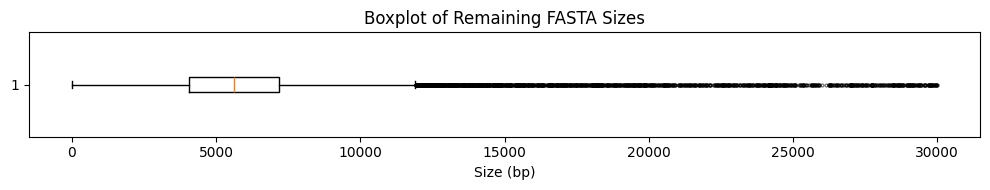

In [8]:
# check bp size of remaining fastas and print min, max, mean, median and boxplot
import pandas as pd
from pathlib import Path   
import matplotlib.pyplot as plt
import numpy as np
fasta_dir = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta")
lengths = []
for fpath in fasta_dir.glob("*"):
    length = 0
    with fpath.open() as f:
        for line in f:
            if line.startswith(">"):
                continue
            length += len(line.strip())
    lengths.append(length)
lengths = np.array(lengths)
print(f"\nMin FASTA length: {lengths.min()} bp")
print(f"Max FASTA length: {lengths.max()} bp")
print(f"Mean FASTA length: {lengths.mean():.2f} bp")
print(f"Median FASTA length: {np.median(lengths)} bp")
plt.figure(figsize=(10, 2), dpi=100)
plt.boxplot(lengths, vert=False, 
            flierprops=dict(marker='.', markersize=4, alpha=0.5))
plt.xlabel("Size (bp)")
plt.title("Boxplot of Remaining FASTA Sizes")
plt.tight_layout()
plt.show()



In [9]:
# number of fastas with 0 bp
zero_length_fastas = [p for p in fasta_dir.glob("*") if p.stat().st_size == 0]
print(f"\nNumber of FASTA files with 0 bp: {len(zero_length_fastas)}")
if zero_length_fastas:
    print("Sample of 0 bp FASTA files:")
    print(zero_length_fastas[:10])


Number of FASTA files with 0 bp: 15
Sample of 0 bp FASTA files:
[PosixPath('/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/IMGPR_plasmid_3300039372_000005.fasta'), PosixPath('/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/IMGPR_plasmid_3300039384_000008.fasta'), PosixPath('/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/IMGPR_plasmid_3300039374_000003.fasta'), PosixPath('/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/IMGPR_plasmid_3300039367_000007.fasta'), PosixPath('/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/IMGPR_plasmid_3300039368_000007.fasta'), PosixPath('/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/IMGPR_plasmid_3300039360_000003.fasta'), PosixPath('/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/IMGPR_plasmid_3300039357_000025.fasta'), PosixPath('/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta/IMGPR_p

In [ ]:
# list of sources in remaining fastas
GenBank    18711
RefSeq     15998
PLDSB       6815
IMG-PR      5670
DDBJ        1374
COMPASS     1160
ENA          465
Kraken2       49
TPA            1


Plasmid length summary by source:


,Source,count,min,max,mean,median
0,ADDGENE,10304,381,23969,6063.121894,5945.0
1,COMPASS,334,1304,29433,6557.805389,5167.0
2,DDBJ,368,990,27490,5157.730978,4084.0
3,GenBank,3022,1021,29812,5856.794176,4350.5
4,IMGPR,1,6147,6147,6147.000000,6147.0
5,PLSDB,211,292,29825,6124.943128,4087.0
6,RefSeq,245,289,29023,6716.963265,5143.0


<Figure size 1200x600 with 0 Axes>

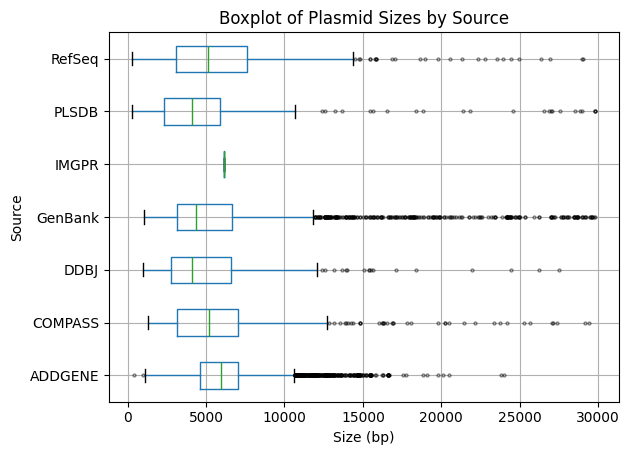

In [1]:
# stats and boxplot of plasmid sequence lengths by source e.g. files starting with: GenBank, RefSeq, PLSDB, IMG-PR, DDBJ, COMPASS, ADDGENE ...
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
fasta_dir = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta")
data = []
for fpath in fasta_dir.glob("*"):
    length = 0
    with fpath.open() as f:
        for line in f:
            if line.startswith(">"):
                continue
            length += len(line.strip())
    # Determine source from filename prefix
    if fpath.name.startswith("GenBank_"):
        source = "GenBank"
    elif fpath.name.startswith("RefSeq_"):
        source = "RefSeq"
    elif fpath.name.startswith("PLSDB_"):
        source = "PLSDB"
    elif fpath.name.startswith("IMGPR_"):
        source = "IMGPR"
    elif fpath.name.startswith("DDBJ_"):
        source = "DDBJ"
    elif fpath.name.startswith("COMPASS_"):
        source = "COMPASS"
    elif fpath.name.startswith("ADDGENE_"):
        source = "ADDGENE"
    else:
        source = "Other"
    data.append((fpath.name, length, source))
df = pd.DataFrame(data, columns=["Filename", "Length", "Source"])
# Summary stats by source
summary = df.groupby("Source")["Length"].agg(['count', 'min', 'max', 'mean', 'median']).reset_index()
print("\nPlasmid length summary by source:")
display(summary)
# Boxplot by source
plt.figure(figsize=(12, 6), dpi=100)
df.boxplot(column="Length", by="Source", vert=False, flierprops=dict(marker='.', markersize=4, alpha=0.5))
plt.xlabel("Size (bp)")
plt.title("Boxplot of Plasmid Sizes by Source")
plt.suptitle("")  # Suppress the automatic 'Boxplot grouped by group_by_column' title
plt.tight_layout()
plt.show()  


